Normalizzazione, standarizzazione e cluster

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler


In [2]:
wine = load_wine()
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [4]:
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

df = pd.concat([X, y], axis=1)

print(df.iloc[[55, 110, 155]])

     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
55     13.56        1.73  2.46               20.5      116.0           2.96   
110    11.46        3.74  1.82               19.5      107.0           3.18   
155    13.17        5.19  2.32               22.0       93.0           1.74   

     flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
55         2.78                  0.20             2.45             6.25  0.98   
110        2.58                  0.24             3.58             2.90  0.75   
155        0.63                  0.61             1.55             7.90  0.60   

     od280/od315_of_diluted_wines  proline  target  
55                           3.03   1120.0       0  
110                          2.81    562.0       1  
155                          1.48    725.0       2  


1. Normalizzazione

In [5]:
scaler_nomr = MinMaxScaler()
X_norm = pd.DataFrame(scaler_nomr.fit_transform(X), columns=X.columns)

print (X_norm.iloc[[55, 110, 155]].T)


                                   55        110       155
alcohol                       0.665789  0.113158  0.563158
malic_acid                    0.195652  0.592885  0.879447
ash                           0.588235  0.245989  0.513369
alcalinity_of_ash             0.510309  0.458763  0.587629
magnesium                     0.500000  0.402174  0.250000
total_phenols                 0.682759  0.758621  0.262069
flavanoids                    0.514768  0.472574  0.061181
nonflavanoid_phenols          0.132075  0.207547  0.905660
proanthocyanins               0.643533  1.000000  0.359621
color_intensity               0.424061  0.138225  0.564846
hue                           0.406504  0.219512  0.097561
od280/od315_of_diluted_wines  0.644689  0.564103  0.076923
proline                       0.600571  0.202568  0.318830


2. Standardizzazione

In [6]:
scaler_std = StandardScaler()
X_std = pd.DataFrame(scaler_std.fit_transform(X), columns=X.columns)

print(X_std.iloc[[55, 110, 155]].T)



                                   55        110       155
alcohol                       0.690985 -1.903071  0.209232
malic_acid                   -0.544297  1.260006  2.561618
ash                           0.341713 -1.997705 -0.170035
alcalinity_of_ash             0.301803  0.001518  0.752231
magnesium                     1.141558  0.509638 -0.473348
total_phenols                 1.065370  1.417883 -0.889474
flavanoids                    0.753708  0.552915 -1.404820
nonflavanoid_phenols         -1.304188 -0.981875  1.999513
proanthocyanins               1.505217  3.485073 -0.071658
color_intensity               0.515585 -0.933525  1.229325
hue                           0.098937 -0.910151 -1.568252
od280/od315_of_diluted_wines  0.590845  0.280108 -1.598441
proline                       1.188156 -0.588791 -0.069719


3. Confronto grafico con BoxPlot

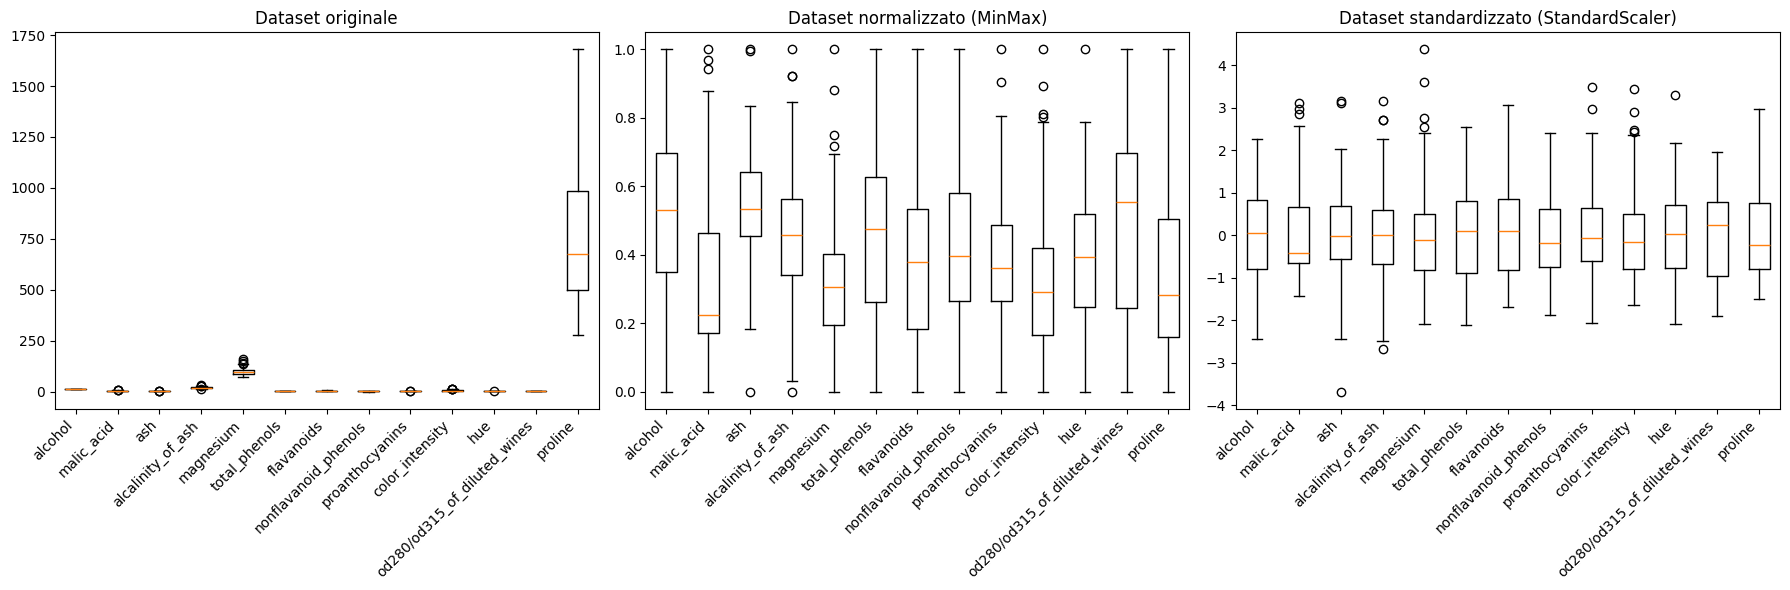

In [7]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.boxplot(X.values)
plt.title("Dataset originale")
plt.xticks(ticks=range(1, len(X.columns) + 1), labels=X.columns, rotation=45, ha= "right")

plt.subplot(1, 3, 2)
plt.boxplot(X_norm.values)
plt.title("Dataset normalizzato (MinMax)")
plt.xticks(ticks=range(1, len(X.columns) + 1), labels=X_norm.columns, rotation=45, ha= "right")

plt.subplot(1, 3, 3)
plt.boxplot(X_std.values)
plt.title("Dataset standardizzato (StandardScaler)")
plt.xticks(ticks=range(1, len(X.columns) + 1), labels=X_std.columns, rotation=45, ha= "right")


plt.tight_layout()
plt.show()


Training di modelli diversi con i tipi di scaling

In [8]:
datasets = [X, X_norm, X_std]

kmeans, knmeans_norm, kmeans_std = [KMeans(n_clusters=3, random_state=42).fit(dataset) for dataset in datasets]

models = [kmeans, knmeans_norm, kmeans_std]


Le labels individuate dai cluster sono 0, 1 e 2 e non si possono confrontare direttamente con le y. Per questo motivo è necessario andare a rimappare ogni cluster alla classe più rappresentata al suo interno attraverso la seguente funzione di cluster accuracy, che:
- rietichetta i cluster in base alla classe prevalente
- calcola l'accuracy come rapporti del numero di campioni corretti su numero di campioni totali

In [9]:
def cluster_accuracy(y, labels):
    labels_pred = np.zeros_like(labels)
    for cluster in np.unique(labels):
        mask = labels == cluster
        most_common = np.bincount(y[mask]).argmax()
        labels_pred[mask] = most_common
    return np.mean(labels_pred == y)


In [10]:
titles =["Originale", "Normalizzato (MinMax)", "Standardizzato (StandardScaler)"]

for title, model in zip(titles, models):
    acc = cluster_accuracy(y, model.labels_)
    print(f"Accuratezza del clustering con dataset {title}: {acc:.3f}")

Accuratezza del clustering con dataset Originale: 0.685
Accuratezza del clustering con dataset Normalizzato (MinMax): 0.949
Accuratezza del clustering con dataset Standardizzato (StandardScaler): 0.966


Plot Kmeans Clustering

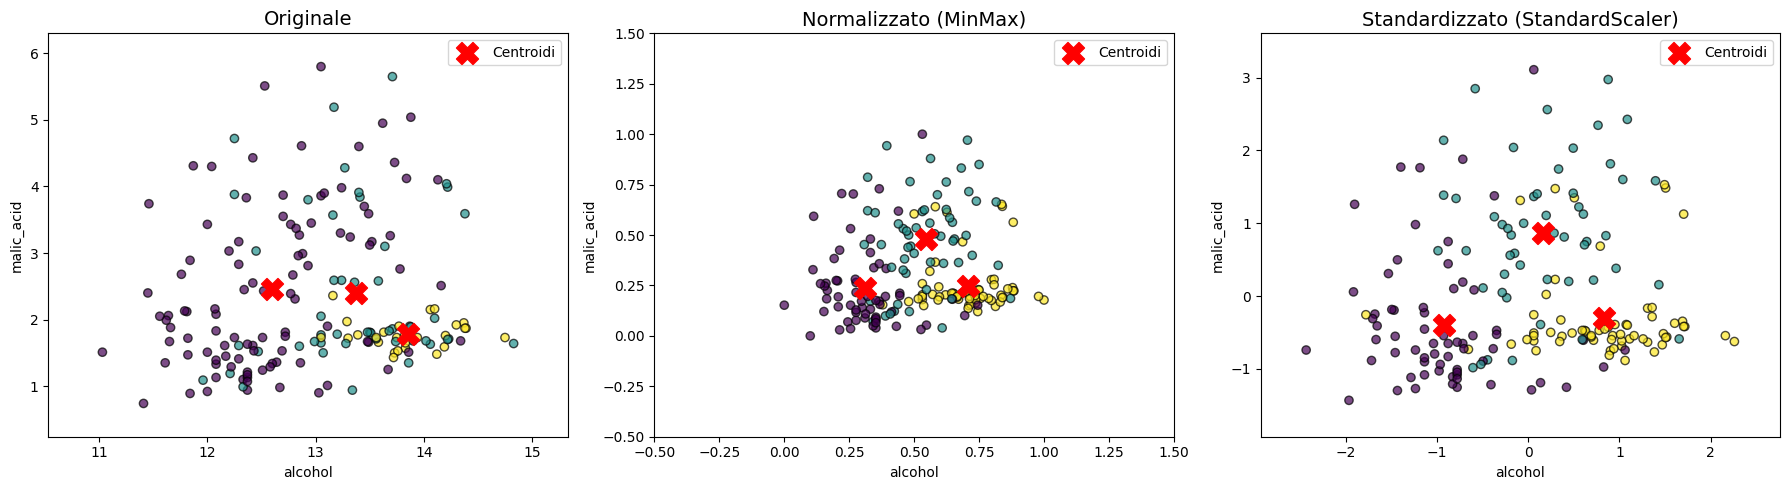

In [11]:
plt.figure(figsize=(18, 5))

for i, (m, d, t) in enumerate(zip(models, datasets, titles)):
    plt.subplot(1, 3, i + 1)
    plt.scatter(d.iloc[:, 0], d.iloc[:, 1], c=m.labels_, cmap="viridis", edgecolor="k", alpha=0.7)
    plt.scatter(m.cluster_centers_[:, 0], m.cluster_centers_[:, 1], c="red", marker="X", s=250, label="Centroidi")
    plt.xlim(d.iloc[:, 0].min() - 0.5, d.iloc[:, 0].max() + 0.5)
    plt.ylim(d.iloc[:, 1].min() - 0.5, d.iloc[:, 1].max() + 0.5)
    plt.title(t, fontsize=14)
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.legend()

plt.tight_layout()
plt.show()
